In [48]:
import numpy as np
import scipy.constants as const
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette("tab10")
e = const.elementary_charge  # Elementary charge in Coulombs
mass_u = const.physical_constants['atomic mass constant'][0]  # Atomic mass unit in kg
hbar = const.hbar  # Reduced Planck's constant in J·s
angstrom = 1e-10  # 1 Angstrom in meters
 
# read data from file
data = np.loadtxt('potential_data', skiprows=1)
x_data = data[:, 0]  # x values in Angstroms
E_data = data[:, 1]  # Energy values in eV

E_shifted = E_data - E_data.min()  # Shift energies so that minimum is at 0 eV

# Preprocessing

### Fits

In [49]:
# --- Quadratic model ---
def quadratic_model(x, a, b, c):
    return a + b * (x - c)**2
guess_quadratic = [0.0, 100.0, 0.0]  # [offset, curvature, center]


# --- Polynomial model (cubic) ---
def polynomial_model(x, a3, a2, a1, a0):
    return a3 * x**3 + a2 * x**2 + a1 * x + a0
guess_polynomial = [0.0, 0.0, -1.0, 1000.0]  # [a3, a2, a1, a0]


# --- Morse potential model ---
def morse_model(x, D_e, a, r_e, offset):
    return D_e * (1 - np.exp(-a * (x - r_e)))**2 + offset
guess_morse = [E_shifted.max() - E_shifted.min(), 1.0, x_data.mean(), E_shifted.min()]  # Initial guess for [D_e, a, r_e, offset]


In [50]:
def fit_model(x, model, guess):
    popt, pcov = curve_fit(model, x, E_shifted, p0=guess)
    return popt, pcov

params_quadratic, _ = fit_model(x_data, quadratic_model, guess_quadratic)
params_polynomial, _ = fit_model(x_data, polynomial_model, guess_polynomial)
params_morse, _ = fit_model(x_data, morse_model, guess_morse)

c:\Users\Francesco\AppData\Local\Anaconda\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


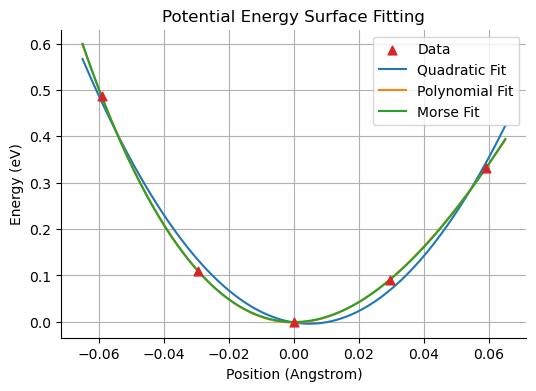

In [51]:
X_axis = np.linspace(x_data.min()*1.1, x_data.max()*1.1, 200)

plt.figure(figsize=(6, 4))
plt.scatter(x_data, E_shifted, label='Data', marker='^', color=colors[3], s=40, zorder = 5)
plt.plot(X_axis, quadratic_model(X_axis, *params_quadratic), label='Quadratic Fit', color=colors[0])
plt.plot(X_axis, polynomial_model(X_axis, *params_polynomial), label='Polynomial Fit', color=colors[1])
plt.plot(X_axis, morse_model(X_axis, *params_morse), label='Morse Fit', color=colors[2])
plt.xlabel('Position (Angstrom)')
plt.ylabel('Energy (eV)')
plt.title('Potential Energy Surface Fitting')
plt.legend()
plt.grid()
sns.despine()
plt.show()


### Verification model

In [52]:
parameter = params_quadratic[1]*e  # in J 

omega = 265.495409 *1e-3 * e / hbar  # Convert meV to J and then to angular frequency
m_eff = 13.585135873543415 * mass_u  # Effective mass in kg

factor = 0.5 * m_eff * omega**2 * (angstrom**2)  # Conversion in J

conv = factor/parameter

print("Conversion factor from eV to J: ", conv)  # in eV

Conversion factor from eV to J:  0.9798921312901426


# Solving the Schrödinger equation

### Morse potential --> Analytical solution
Eigenenergies: $\epsilon_n/D_e = (2 \lambda -n - \frac{1}{2})(n + \frac{1}{2})$

In [53]:
# convert in SI units for further calculations
D_e = params_morse[0] * e  # in J
a = params_morse[1] / angstrom  # in 1/m
r_e = params_morse[2] * angstrom  # in m
offset = params_morse[3] * e  # in J

# Solving the Schrödinger equation
lambda_param = np.sqrt(2 * m_eff * D_e) / (a * hbar) # see parametrization wikipedia
n_max = int(2 * lambda_param - 0.5)
energy_levels = []
for n in range(10):
    epsilon_n = (2 * lambda_param - n - 0.5) * (n + 0.5) * (hbar * a)**2 / (2 * m_eff)
    energy_levels.append(epsilon_n + offset)

print("Calculated energy levels (in eV):")
for i, energy in enumerate(energy_levels):
    print(f"n={i}: {energy / e:.4f} eV")

Calculated energy levels (in eV):
n=0: 0.1319 eV
n=1: 0.3938 eV
n=2: 0.6525 eV
n=3: 0.9081 eV
n=4: 1.1605 eV
n=5: 1.4097 eV
n=6: 1.6557 eV
n=7: 1.8986 eV
n=8: 2.1382 eV
n=9: 2.3747 eV


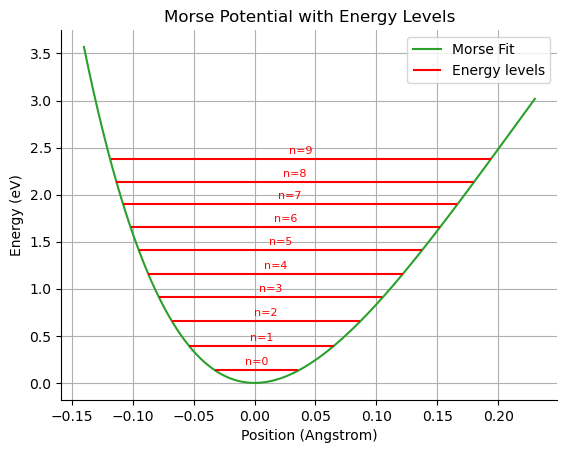

In [54]:
x_vals = np.linspace(-0.14, 0.23, 1000)

plt.plot(x_vals, morse_model(x_vals, *params_morse), label='Morse Fit', color=colors[2])
for n, energy in enumerate(energy_levels):
    min_index = np.where(morse_model(x_vals, *params_morse) <= energy / e)[0][0]
    max_index = np.where(morse_model(x_vals, *params_morse) <= energy / e)[0][-1]
    xi, xj = x_vals[min_index], x_vals[max_index]
    plt.hlines(energy / e, xi, xj, colors='r', label='Energy levels' if n == 0 else "")
    # place level label centered above the line
    xmid = 0.5 * (xi + xj)
    vp = morse_model(x_vals, *params_morse)
    y_offset = 0.01 * (vp.max() - vp.min())
    plt.text(xmid, energy / e + y_offset, f"n={n}", ha='center', va='bottom', color='r', fontsize=8)
    
plt.xlabel('Position (Angstrom)')
plt.ylabel('Energy (eV)')
plt.title('Morse Potential with Energy Levels')
plt.legend()
sns.despine()
plt.grid()

### Harmonic oscillator --> exact solution

In [55]:
params_quadratic

array([-3.98415581e-03,  1.16889882e+02,  4.72126168e-03])

Harmonic oscillator frequency (from quadratic fit): 101799798005068.05
Omega from data 403358532454922.0
Difference in %: 74.7619574611466
First 2 eigenvalues: [-0.00398416 -0.00398416]


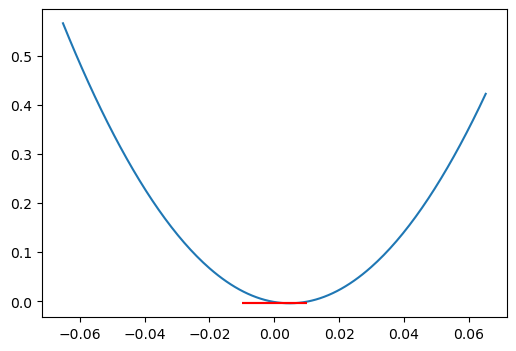

In [75]:
def harmonic_eigenvalues_from_quadratic(params, m, N):
    a, b, c = params # unpack parameters
    omega_quad = np.sqrt(2.0 * b / m) # angular frequency
    n = np.arange(N) # quantum numbers
    En = hbar * omega_quad * (n + 0.5) + a # energy levels
    return En

N = 2
eigenvalues = harmonic_eigenvalues_from_quadratic(params_quadratic, m_eff, N)
print("First", N, "eigenvalues:", eigenvalues)


a, b, c = params_quadratic
plt.figure(figsize=(6, 4))
plt.plot(X_axis, quadratic_model(X_axis, *params_quadratic), label='Quadratic Fit', color=colors[0])
for n, energy in enumerate(eigenvalues):
    plt.hlines(energy, -0.01, 0.01, colors='r', label='Energy levels' if n == 0 else "")
    # place level label centered above the line
    # xmid = 0.5 * (xi + xj)
    # vp = quadratic_model(X_axis, *params_quadratic)
    # y_offset = 0.01 * (vp.max() - vp.min())
    # plt.text(xmid, energy / e + y_offset, f"n={n}", ha='center', va='bottom', color='r', fontsize=8

### Numerical solution 

In [57]:
# --- build grid ----
x_min = -0.1
x_max = 0.15
N = 2000     

x_A = np.linspace(x_min, x_max, N)        # Angstrom coordinate
x = x_A * angstrom                        # meter coordinate
dx = x[1] - x[0]

In [58]:
# --- choose potential from fit (use Morse here) ---
V_eV = morse_model(x_A, *params_morse)    # returns eV
V = V_eV * e                          # convert to J

# enforce high walls to help localization
V[0]  = V[-1] = np.max(V)*2

In [59]:
# --- kinetic (finite-diff) ---
coeff = hbar**2 / (2.0 * m_eff * dx**2)
diag  = 2*coeff + V
off   = -coeff * np.ones(N-1)

# Dirichlet boundary conditions 
H = np.diag(diag) + np.diag(off,1) + np.diag(off,-1)

C:\Users\Francesco\AppData\Local\Temp\ipykernel_17808\1017613776.py:3: DeprecationWarning: Keyword argument 'eigvals' is deprecated in favour of 'subset_by_index' keyword instead and will be removed in SciPy 1.12.0.
  E_J, PSI = eigh(H, eigvals=(0,M-1))


n =  0   E = 0.131896 eV
n =  1   E = 0.394072 eV


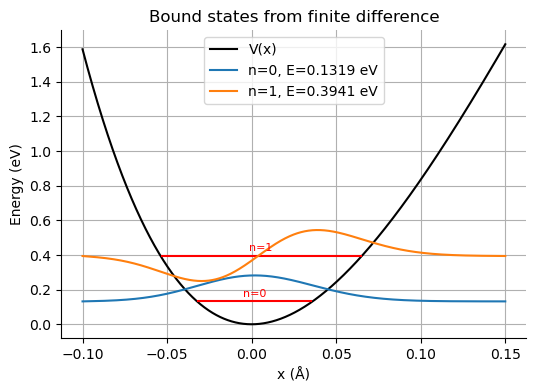

In [60]:
from scipy.linalg import eigh
M = 2
E_J, PSI = eigh(H, eigvals=(0,M-1))
E_eV = E_J / e

# normalize wavefunctions
for n in range(M):
    norm = np.sqrt(np.sum(np.abs(PSI[:,n])**2)*dx)
    PSI[:,n] /= norm

# print eigenenergies
for n in range(M):
    print(f"n = {n:2d}   E = {E_eV[n]:.6f} eV")

# --- plot first few states on top of V ---
plt.figure(figsize=(6,4))
plt.plot(x_A, V_eV, 'k', lw=1.5, label='V(x)')

for n, energy in enumerate(E_eV):
    min_index = np.where(morse_model(x_A, *params_morse) <= energy)[0][0]
    max_index = np.where(morse_model(x_A, *params_morse) <= energy)[0][-1]
    xi, xj = x_A[min_index], x_A[max_index]
    plt.hlines(energy, xi, xj, colors='r')
    # place level label centered above the line
    xmid = 0.5 * (xi + xj)
    vp = morse_model(x_A, *params_morse)
    y_offset = 0.01 * (vp.max() - vp.min())
    plt.text(xmid, energy + y_offset, f"n={n}", ha='center', va='bottom', color='r', fontsize=8)
    plt.plot(x_A, energy + 0.15*PSI[:,n]/np.max(np.abs(PSI[:,n])),
             label=f'n={n}, E={energy:.4f} eV')

plt.xlabel('x (Å)')
plt.ylabel('Energy (eV)')
plt.legend()
plt.title('Bound states from finite difference')
plt.grid(True)
sns.despine()
plt.show()


--- QuTiP eigenvalues (eV) ---
n =  0   E = 0.131896 eV
n =  1   E = 0.394072 eV


c:\Users\Francesco\AppData\Local\Anaconda\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Francesco\AppData\Local\Anaconda\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


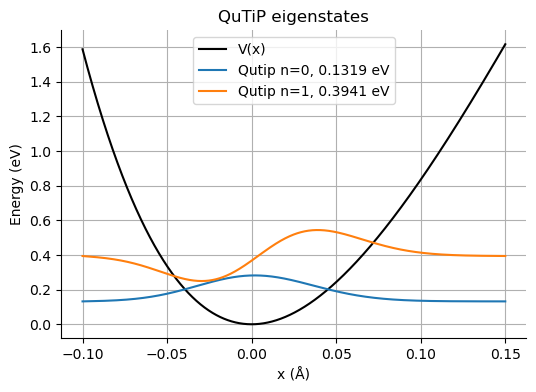

In [61]:
# ===================== QUTIP SOLUTION =====================

import qutip as qt

# wrap the finite-difference Hamiltonian H (numpy array) into Qobj
H_q = qt.Qobj(H)

# compute lowest M eigenenergies/eigenstates
evals_q, evecs_q = H_q.eigenstates()   # returns all; slice if needed
evals_q_eV = np.array(evals_q)/e   # convert J -> eV

# print first few
print("\n--- QuTiP eigenvalues (eV) ---")
for n in range(M):
    print(f"n = {n:2d}   E = {evals_q_eV[n]:.6f} eV")

# plot first few states using the same x-grid
plt.figure(figsize=(6,4))
plt.plot(x_A, V_eV, 'k', lw=1.5, label='V(x)')

for n in range(min(M,4)):
    psi_q = np.array(evecs_q[n].full()).flatten()       # Qobj → numpy
    # normalize (should already be norm=1 but do it for safety)
    psi_q /= np.sqrt(np.sum(np.abs(psi_q)**2)*dx)
    plt.plot(x_A, evals_q_eV[n] + 0.15*psi_q/np.max(np.abs(psi_q)),
             label=f'Qutip n={n}, {evals_q_eV[n]:.4f} eV')

plt.xlabel('x (Å)')
plt.ylabel('Energy (eV)')
plt.legend()
plt.title('QuTiP eigenstates')
plt.grid(True)
sns.despine()
plt.show()